# Case 2a -- Local Changes in Relative Cross-Section Area (Maize Root)

**Dissertation Chapter 6, Section 6.2.1, "Local Changes in Relative Cross-Section Area" (p. 113):**

> To investigate the tracer data using the MCT model, a network of coupled unit operations was
> constructed, representing individual root segments with independent transport properties for
> each ROI. As the decay-corrected TACs (Figure fig:area_change_hmax a) show no noticeable
> decrease in peak amplitude, storage effects were considered negligible in this case.

- Data: 4 ROIs along the lower segment of a maize primary root (`230816_M06_Au06_Primary.txt`).
- Model: 3 coupled MCT (model M01) unit operations with independently fitted relative
  cross-sectional areas; dispersion fixed to zero.
- Reproduces: Figure `fig:local_v_mct` (`Figures/mct_local.pdf`) and Table `tab:maize_velocity`.
- Half-maximum preliminary analysis (Figure `fig:area_change_hmax`) is in the companion notebook
  `case2a_preliminary_hmax_maize_root.ipynb`.

## Imports

In [90]:
from CADETProcess.processModel import Inlet, MCT, Outlet
from CADETProcess.processModel import ComponentSystem, MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet, Process
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr

from IPython import display

from utils import compute_jacobian, compute_parameter_uncertainties, interpolate_cb_from_simulation_results, plot_all_columns, plot_live_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
import os
os.makedirs("output/figures", exist_ok=True)


## Load experimental data

In [92]:
df = pd.read_csv("data/case2a_maize_root.csv", index_col=0)
df.columns = df.columns.astype(float)  # CSV headers are strings; these are numeric distances (mm)


In [93]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

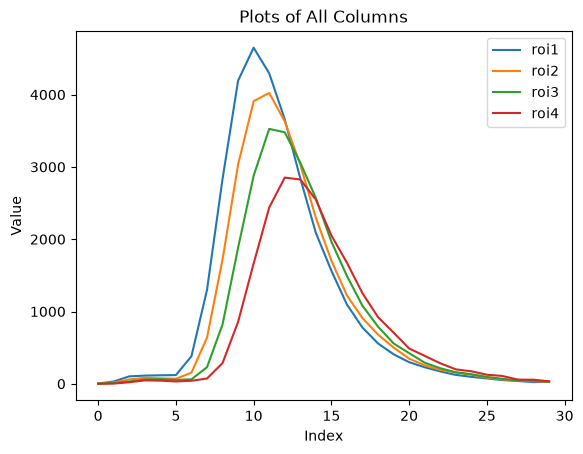

In [94]:
rois = plot_all_columns(data_unc[:,11:15])
xi=xi[11:15]

Decay-corrected data, shown for comparison with the uncorrected data used for fitting above.

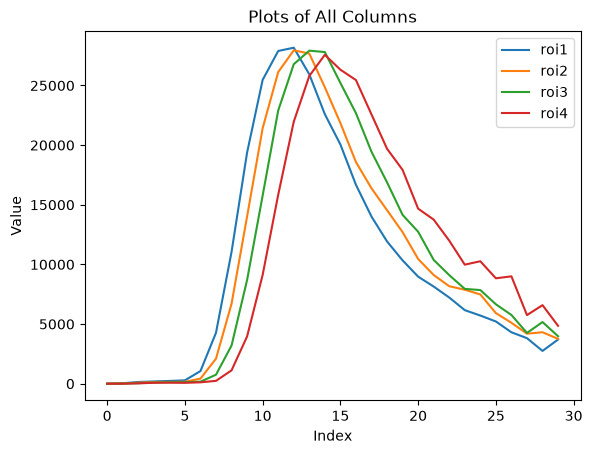

In [95]:
rois_cor = plot_all_columns(data_cor[:,11:15])

In [96]:
roi1 = rois['roi1']
roi2 = rois['roi2']
roi3 = rois['roi3']
roi4 = rois['roi4']

exp_data = np.hstack((roi1,roi2,roi3,roi4)).reshape(4,30).T
exp_data = exp_data / np.max(exp_data)

weights = 1 / np.mean(exp_data, axis=0)

## Process model

In [97]:

def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct2_relA = x[1]
    p_mct3_relA = x[2]
    p_col_dispersion = x[3]
    p_t0 = x[4]
    
    
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=1, name='mct1')
    mct2 = MCT(component_system, nchannel=1, name='mct2')
    mct3 = MCT(component_system, nchannel=1, name='mct3')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(outlet)

    v_lrmp = 4e-05

    leaf.total_porosity = 9.20711785e-01
    leaf.length = 9.12398615e-02 
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000-xi[0]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    
    mct1.channel_cross_section_areas = [1]
    mct2.channel_cross_section_areas = [p_mct2_relA] 
    mct3.channel_cross_section_areas = [p_mct3_relA] 
    
    mct1.axial_dispersion = 0
    mct2.axial_dispersion = 0
    mct3.axial_dispersion = 0
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0]],
                                    ])
    
    mct2.exchange_matrix = np.array([
                                    [[0.0]],
                                    ])
    mct3.exchange_matrix = np.array([
                                    [[0.0]],
                                    ])

    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

## Parameter normalization

In [98]:
param_bounds = {
    'q_const': (1e-05, 1.5e-04),  # log-scaling
    'mct2_relA': (1, 1.8),
    'mct3_relA': (1, 1.8),
    'col_dispersion': (1e-09, 1e-06),  # log-scaling
    't0': (0.01, 20),  # linear scaling
}

problem = OptimizationProblem("case2a_velocity_change")
for name, (lb, ub) in param_bounds.items():
    problem.add_variable(name, evaluation_objects=None, lb=lb, ub=ub, normalization="auto")


## Objective function

`_forward_model` runs the simulation once; `objective` (scalar SSQ, for the optimizer) and
`residuals` (residual vector, for the Jacobian/uncertainty estimate below) both build on it
instead of duplicating the simulation call.

In [99]:
def _forward_model(x):
    """Simulate the process; return (calc_data, time_new)."""
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0] * 60, t[-1] * 60 + 5 * 60, 5 * 60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    eval_location1 = [0]
    eval_location2 = [0]
    eval_location3 = [0] + [xi[3] / 1000 - xi[2] / 1000]

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new=eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T

    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new=eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new=eval_location3)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()

    calc_data = np.hstack((calc_data_mct1, calc_data_mct2, calc_data_mct3))
    calc_data = calc_data / np.max(calc_data)

    return calc_data, time_new

def objective(x):
    """NMSRE = mean((calc - exp)^2) / mean(exp^2); used as the optimizer's objective."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    nmsre = np.mean(residuals ** 2) / np.mean(exp_data ** 2)
    _obj_history.append(nmsre)
    if _live_plot_active:
        plot_live_fit(time_new, calc_data, exp_data, _obj_history)
    return nmsre

def residuals(x):
    """Raw residual vector; used for the numerical Jacobian / uncertainty estimate."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    return residuals.ravel() / np.sqrt(np.mean(exp_data ** 2))

problem.add_objective(objective, n_objectives=1)

## Plotting and reporting helpers

In [100]:
_obj_history = []
_live_plot_active = False

In [101]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = False

## Optimization

Starting point `x0` is the fit behind the originally published `tab:maize_velocity`
(preserved here for provenance). A local refinement (Nelder-Mead, then L-BFGS-B) finds the
improved fit that was already used for the published `fig:local_v_mct` figure.

In [102]:
x_best_fit_published = np.array([5.66310782e-05, 1.20601434e+00, 1.42959784e+00, 3.37004795e-07, 1.70590259e+00])

#Relates to the table, but is a little worse fit than the one above, qualitalively the same
original_x_published = np.array([6.27797735e-05, 1.28573293e+00, 1.50936054e+00, 2.40703476e-07,
 1.48044656e+00])

def run_optimization(optimize=False, live_plot=False, method="nm+tc", x0=None):
    """
    optimize  : False  return x_best_fit_published without running the optimizer
                True   run the optimizer and return the converged x
    method    : "nm"     NelderMead only
                "tc"     TrustConstr only
                "nm+tc"  NelderMead then TrustConstr
                "tc+nm"  TrustConstr then NelderMead
    x0        : starting point in real units; defaults to x_best_fit_published
    live_plot : show live fit and objective progress during optimization
    """
    global _live_plot_active, _obj_history
    if not optimize:
        return x_best_fit_published

    if x0 is None:
        x0 = x_best_fit_published

    _live_plot_active = live_plot
    _obj_history = []

    if method in ("nm", "nm+tc"):
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    if method in ("tc", "nm+tc", "tc+nm"):
        tc = TrustConstr()
        tc.gtol = 1e-5
        tc.xtol = 1e-5
        tc.barrier_tol = 1e-5
        result_tc = tc.optimize(problem, x0=x0, save_results=False)
        x0 = result_tc.x[0]

    if method == "tc+nm":
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    x_best_fit = x0
    for pname, value in zip(param_bounds.keys(), x_best_fit):
        print(f"{pname:<35}{value:<20.8e}")
    _live_plot_active = False
    return x_best_fit

x_best_fit = run_optimization()

## Final fit figure (`fig:local_v_mct`, `Figures/mct_local.pdf`)

In [103]:
def plot_for_publication(x):

    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = [0]
    eval_location2 = [0]
    eval_location3 = [0] + [xi[3]/1000-xi[2]/1000]

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 =  np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 =  np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 =  np.sum(cb_mct3, axis=2).squeeze()

    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)
  
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14) 
    
    plt.plot(calc_data, label="Simulated Data", linewidth=1.5)
    plt.gca().set_prop_cycle(None)
    plt.plot(t,exp_data, '.',  markersize=8,label="Experimental Data",)
    
    plt.xlabel("Time [min]")
    plt.ylabel("Activity [a.u.]")
    
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=10)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    
    plt.savefig("output/figures/mct_local.pdf", format="pdf")  

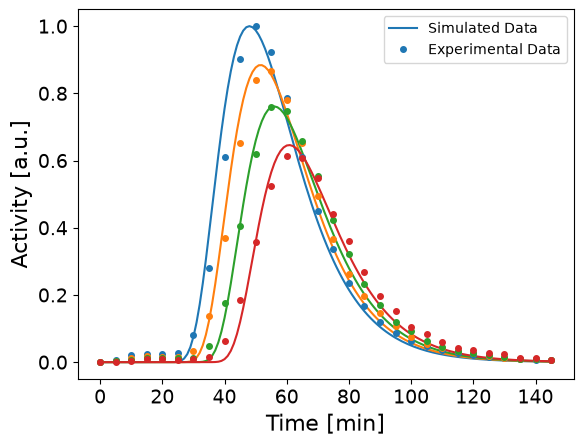

In [104]:
plt.close("all") 
plot_for_publication(x_best_fit)

## Updated velocity/area table

Supersedes the originally published `tab:maize_velocity` -- see the note at the top of this
notebook.

In [105]:
def calculate_velocities(x, area_indices):
    """Compute velocities (mm/min) for each tube from optimized parameters."""
    flow_velocity_m_s = x[0]  # q_const: interstitial velocity in tube 1 [m/s]
    relative_areas = [x[i] for i in area_indices]

    areas = [1.0] + [rel for rel in relative_areas]  # tube 1 is reference (area = 1)
    velocities = [(flow_velocity_m_s / area) * 1e3 * 60 for area in areas]

    tube_names = ["Tube 1"] + [f"Tube {i+2}" for i in range(len(relative_areas))]
    return pd.DataFrame({
        "Tube": tube_names,
        "Relative area": areas,
        "Velocity (mm/min)": velocities,
    })

def relative_parameter_uncertainties(x):
    """Relative uncertainty per parameter [fraction] from the residual Jacobian/covariance."""
    return compute_parameter_uncertainties(residuals, x) / np.abs(x)

def velocity_table_with_uncertainty(x, area_indices):
    """Velocity/area table with quadrature-propagated uncertainty (v = q_const / rel_area)."""
    table = calculate_velocities(x, area_indices)
    rel_unc = relative_parameter_uncertainties(x) * 100  # percent

    flow_rel_error = rel_unc[0]
    area_rel_errors = [0.0] + [rel_unc[i] for i in area_indices]

    table["Rel. error area (%)"] = area_rel_errors
    table["Rel. error velocity (%)"] = np.sqrt(flow_rel_error**2 + np.array(area_rel_errors)**2)
    return table

In [106]:
velocity_table_with_uncertainty(x_best_fit, area_indices=[1, 2])

,Tube,Relative area,Velocity (mm/min),Rel. error area (%),Rel. error velocity (%)
0,Tube 1,1.000000,3.397865,0.000000,2.687649
1,Tube 2,1.206014,2.817433,8.265803,8.691775
2,Tube 3,1.429598,2.376798,8.726479,9.130985
